# Build a predictor function to predict proce of a hone
# 1) With 3400 sqr ft area in west windsor
# 2) 2800 price for robbinsville

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,LinearRegression
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [6]:
os.chdir("C:\\Users\\Harsh\\Downloads\\skill-set-go-AIML-B1-0343-Yash_Veer_Singh\\skillset-go-aiml-internship\\skillset-go-aiml-internship\\Week-1\\Task-1.4-Scikit-Learn-Models\\First_Model")

In [7]:
df=pd.read_csv('dummyvalue.csv')

In [8]:
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robbinsville,2600,575000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   town    12 non-null     object
 1   area    12 non-null     int64 
 2   price   12 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 420.0+ bytes


In [10]:
df.describe()

,area,price
count,12.000000,12.000000
mean,3108.333333,623750.000000
std,452.183256,56533.377108
min,2600.000000,550000.000000
25%,2750.000000,582500.000000
50%,3050.000000,612500.000000
75%,3375.000000,657500.000000
max,4000.000000,725000.000000


# how to convert categorical values into number
# like this:
#   town	area	price
# 0	1	2600	550000
# 1	1	3000	565000
# 2	1	3200	610000
# 3	1	3600	680000
# 4	1	4000	725000
# 5	2	2600	585000
# 6	2	2800	615000
# 7	2	3300	650000
# 8	2	3600	710000
# 9	3	2600	575000
# 10	3	2900	600000
# 11	3	3100	620000
# We can also do OnehotEncoding

In [11]:
print(df['town'])
print(df.town)

0     monroe township
1     monroe township
2     monroe township
3     monroe township
4     monroe township
5        west windsor
6        west windsor
7        west windsor
8        west windsor
9        robbinsville
10       robbinsville
11       robbinsville
Name: town, dtype: object
0     monroe township
1     monroe township
2     monroe township
3     monroe township
4     monroe township
5        west windsor
6        west windsor
7        west windsor
8        west windsor
9        robbinsville
10       robbinsville
11       robbinsville
Name: town, dtype: object


In [12]:
dummies=pd.get_dummies(df['town'])
dummies
#how to add column in dataframe object

,monroe township,robbinsville,west windsor
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,False,False,True
6,False,False,True
7,False,False,True
8,False,False,True
9,False,True,False


In [13]:
merged=pd.concat([df,dummies],axis=1)
merged

,town,area,price,monroe township,robbinsville,west windsor
0,monroe township,2600,550000,True,False,False
1,monroe township,3000,565000,True,False,False
2,monroe township,3200,610000,True,False,False
3,monroe township,3600,680000,True,False,False
4,monroe township,4000,725000,True,False,False
5,west windsor,2600,585000,False,False,True
6,west windsor,2800,615000,False,False,True
7,west windsor,3300,650000,False,False,True
8,west windsor,3600,710000,False,False,True
9,robbinsville,2600,575000,False,True,False


In [14]:
final=merged.drop('town', axis=1)
final

,area,price,monroe township,robbinsville,west windsor
0,2600,550000,True,False,False
1,3000,565000,True,False,False
2,3200,610000,True,False,False
3,3600,680000,True,False,False
4,4000,725000,True,False,False
5,2600,585000,False,False,True
6,2800,615000,False,False,True
7,3300,650000,False,False,True
8,3600,710000,False,False,True
9,2600,575000,False,True,False


<Axes: >

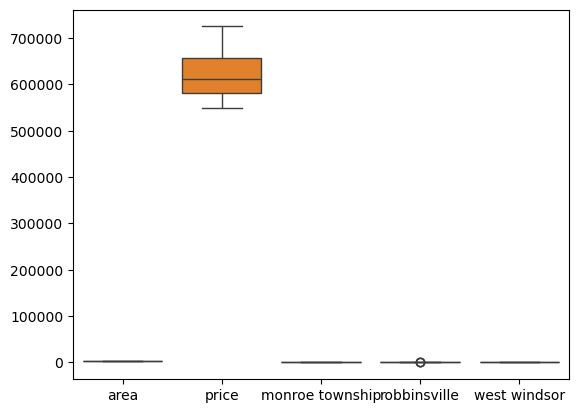

In [15]:
sns.boxplot(final)

In [16]:
model1=Ridge()
model2=LinearRegression()
model=[model1,model2]

In [17]:
x=final.drop('price',axis=1)
y=final['price']

In [18]:
X_train,x_test,Y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=2)

In [19]:
for model_name in model:
     model_name.fit(X_train,Y_train)
     score=model_name.score(x_test,y_test)
     print(score)

0.9553562133060323
0.9323433184633599


In [20]:
0.9553562133060323-0.9323433184633596

0.02301289484267266

In [21]:
for model_name in model:
    prediction=model_name.predict([[3400,0,0,1]])

c:\Users\Harsh\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\Harsh\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
print(prediction)

[687965.11627907]


In [23]:
#(.values) convert into arrays
# [] 1D array
# [[]] 2D array
print(df['town'])
print(df[['town']])
print(df['town'].values)
print(df[['town']].values)

0     monroe township
1     monroe township
2     monroe township
3     monroe township
4     monroe township
5        west windsor
6        west windsor
7        west windsor
8        west windsor
9        robbinsville
10       robbinsville
11       robbinsville
Name: town, dtype: object
               town
0   monroe township
1   monroe township
2   monroe township
3   monroe township
4   monroe township
5      west windsor
6      west windsor
7      west windsor
8      west windsor
9      robbinsville
10     robbinsville
11     robbinsville
['monroe township' 'monroe township' 'monroe township' 'monroe township'
 'monroe township' 'west windsor' 'west windsor' 'west windsor'
 'west windsor' 'robbinsville' 'robbinsville' 'robbinsville']
[['monroe township']
 ['monroe township']
 ['monroe township']
 ['monroe township']
 ['monroe township']
 ['west windsor']
 ['west windsor']
 ['west windsor']
 ['west windsor']
 ['robbinsville']
 ['robbinsville']
 ['robbinsville']]


In [24]:
df1=df.copy()
ohe=OneHotEncoder(categories='auto',sparse_output=False)
#sparse_output=False to do so that we get ndarray not the sparse matrix
#df1[['town']]=ohe.fit_transform(df1[['town']])
                   # or
encoded=ohe.fit_transform(df1[['town']])
print(encoded)
print(encoded.shape)
encoded_df1=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(['town']))
print(encoded_df1)
# here the OneHotEncoder --> fit_transfrom require 2D array and stores in 2D array
df1 = df1.drop('town', axis=1)
df1 = pd.concat([encoded_df1, df1], axis=1)
df1

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]
(12, 3)
    town_monroe township  town_robbinsville  town_west windsor
0                    1.0                0.0                0.0
1                    1.0                0.0                0.0
2                    1.0                0.0                0.0
3                    1.0                0.0                0.0
4                    1.0                0.0                0.0
5                    0.0                0.0                1.0
6                    0.0                0.0                1.0
7                    0.0                0.0                1.0
8                    0.0                0.0                1.0
9                    0.0                1.0                0.0
10                   0.0                1.0                0.0
11                   0.0                1.0                0.0


,town_monroe township,town_robbinsville,town_west windsor,area,price
0,1.0,0.0,0.0,2600,550000
1,1.0,0.0,0.0,3000,565000
2,1.0,0.0,0.0,3200,610000
3,1.0,0.0,0.0,3600,680000
4,1.0,0.0,0.0,4000,725000
5,0.0,0.0,1.0,2600,585000
6,0.0,0.0,1.0,2800,615000
7,0.0,0.0,1.0,3300,650000
8,0.0,0.0,1.0,3600,710000
9,0.0,1.0,0.0,2600,575000


In [25]:
df1

,town_monroe township,town_robbinsville,town_west windsor,area,price
0,1.0,0.0,0.0,2600,550000
1,1.0,0.0,0.0,3000,565000
2,1.0,0.0,0.0,3200,610000
3,1.0,0.0,0.0,3600,680000
4,1.0,0.0,0.0,4000,725000
5,0.0,0.0,1.0,2600,585000
6,0.0,0.0,1.0,2800,615000
7,0.0,0.0,1.0,3300,650000
8,0.0,0.0,1.0,3600,710000
9,0.0,1.0,0.0,2600,575000


In [26]:
le=LabelEncoder()

In [27]:
data_with_labelencoder=df

In [28]:
print(le.fit(data_with_labelencoder.town))
data_with_labelencoder.town=le.fit_transform(data_with_labelencoder.town)

LabelEncoder()


In [29]:
data_with_labelencoder

,town,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,610000
3,0,3600,680000
4,0,4000,725000
5,2,2600,585000
6,2,2800,615000
7,2,3300,650000
8,2,3600,710000
9,1,2600,575000


In [30]:
x=data_with_labelencoder[['town','area']].values

In [31]:
x

array([[   0, 2600],
       [   0, 3000],
       [   0, 3200],
       [   0, 3600],
       [   0, 4000],
       [   2, 2600],
       [   2, 2800],
       [   2, 3300],
       [   2, 3600],
       [   1, 2600],
       [   1, 2900],
       [   1, 3100]])

In [32]:
y=data_with_labelencoder.price

In [33]:
y

0     550000
1     565000
2     610000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
Name: price, dtype: int64

In [34]:
mod1=Ridge()
mod2=LinearRegression()
mod=[mod1,mod2]

In [35]:
x=df1.drop('price',axis=1)
y=df1['price']

In [36]:
X_train,x_test,Y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=2)

In [37]:
for model in mod:
     model.fit(X_train,Y_train)
     prediction = model.predict([[0,0,1,3400]])
     score=model.score(x_test,y_test)
     print(f"the score of model name: {model} is : {score}")
     print(f"the prediction of model name : {model} is : {prediction}")

the score of model name: Ridge() is : 0.9553562133060322
the prediction of model name : Ridge() is : [679565.80512503]
the score of model name: LinearRegression() is : 0.9323433184633608
the prediction of model name : LinearRegression() is : [687965.11627907]


c:\Users\Harsh\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\Harsh\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
